# 06 - Recurrent Neural Network (RNN)



---

In the previous notebook, we learned about the Sequence Problem.

Traditional NLP models like Bag of Words, TF-IDF, Word2Vec, GloVe, and FastText cannot understand word order.

To solve this problem, researchers developed **Recurrent Neural Networks (RNNs)**.

In this notebook, we will understand how RNNs remember previous information while processing sequences.

## 📜 History

Before RNNs, most NLP models processed words independently.

They had no memory of previous words.

Researchers wanted a neural network that could:

- Read words one at a time.
- Remember previous words.
- Use previous information to understand the current word.

This led to the development of the **Recurrent Neural Network (RNN)**.

The key innovation of RNN is its **Hidden State**, which acts like memory.

## ❌ Limitations of Word Embeddings

Word2Vec, GloVe, and FastText generate vectors for individual words.

Example:

I love AI

↓

I → Vector

love → Vector

AI → Vector

But they do not know that:

I

comes before

love

or that

love

comes before

AI.

They also cannot remember previous words while processing a sentence.

We need a model with memory.

## 💡 Core Idea

An RNN reads a sentence one word at a time.

Instead of forgetting previous words,

it stores information in a **Hidden State**.

The hidden state is updated after every new word.

Previous Memory

↓

Current Word

↓

New Memory

↓

Next Word

## 🧠 Human Analogy

Imagine someone says:

"I love learning Artificial Intelligence."

You don't forget the word **I** when you hear **love**.

Your brain remembers previous words while listening.

RNN works in a similar way.

It carries information from one time step to the next using its hidden state.

In [2]:
sentence = "I love learning AI"

words = sentence.split()

for i, word in enumerate(words):

    print(f"Step {i+1}")

    print("Current Word:", word)

    print()

Step 1
Current Word: I

Step 2
Current Word: love

Step 3
Current Word: learning

Step 4
Current Word: AI



In [5]:
# Simulating Memory
sentence = "I love learning AI"

words = sentence.split()

memory = ""

for word in words:

    memory += word + " "

    print("Current Word :", word)

    print("Memory :", memory)

    print("-"*30)
    #This is exactly what an RNN tries to achieve—but with learned numerical representations instead of plain text.

Current Word : I
Memory : I 
------------------------------
Current Word : love
Memory : I love 
------------------------------
Current Word : learning
Memory : I love learning 
------------------------------
Current Word : AI
Memory : I love learning AI 
------------------------------


## 📊 RNN Architecture

```
Input Word
     │
     ▼
Embedding
     │
     ▼
Hidden State (Memory)
     │
     ▼
Output
     │
     ▼
Next Time Step
```

The hidden state is passed from one step to the next.

This makes the network "recurrent."

In [7]:
sentence = "Deep Learning is amazing"

words = sentence.split()

for time_step, word in enumerate(words):

    print(f"Time Step {time_step}")

    print("Input :", word)

    print()
    #Explain that each word is processed at a different time step.

Time Step 0
Input : Deep

Time Step 1
Input : Learning

Time Step 2
Input : is

Time Step 3
Input : amazing



In [9]:
# Hidden State Comcept
hidden_state = 0

numbers = [2, 5, 1, 3]

for number in numbers:

    hidden_state = hidden_state + number

    print("Input :", number)

    print("Hidden State :", hidden_state)

    print()
    #This is not a real RNN, but it demonstrates that the hidden state changes after each input.

Input : 2
Hidden State : 2

Input : 5
Hidden State : 7

Input : 1
Hidden State : 8

Input : 3
Hidden State : 11



## ➗ Mathematics

The hidden state is updated using:

\[
h_t = \tanh(W_x  x_t  +  W_h  h_{t-1}  +  b)
\]

Where:

- \(x_t\) = current input
- \(h_{t-1}\) = previous hidden state
- \(h_t\) = new hidden state
- \(W_x\) = input weights
- \(W_h\) = hidden-state weights
- \(b\) = bias

The tanh activation keeps values between -1 and 1.

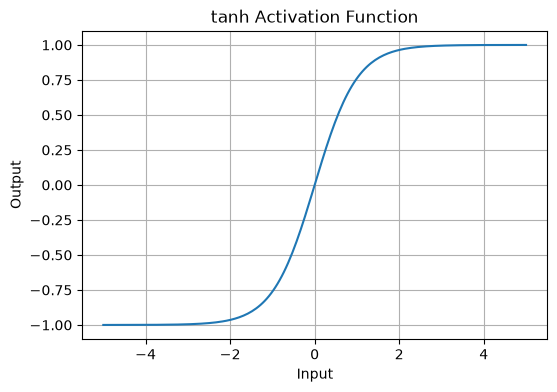

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 200)

y = np.tanh(x)

plt.figure(figsize=(6,4))

plt.plot(x, y)

plt.title("tanh Activation Function")

plt.xlabel("Input")

plt.ylabel("Output")

plt.grid()

plt.show()

In [11]:
import numpy as np

Wx = 0.5
Wh = 0.8

hidden = 0

inputs = [1,2,3]

for x in inputs:

    hidden = np.tanh(Wx*x + Wh*hidden)

    print(hidden)

0.46211715726000974
0.8786223746838898
0.9758816208890569


In [12]:
import torch
import torch.nn as nn

rnn = nn.RNN(
    input_size=5,
    hidden_size=3,
    batch_first=True
)

print(rnn)

RNN(5, 3, batch_first=True)


In [13]:
x = torch.randn(1,4,5)

output, hidden = rnn(x)

print("Output Shape :", output.shape)

print("Hidden Shape :", hidden.shape)

Output Shape : torch.Size([1, 4, 3])
Hidden Shape : torch.Size([1, 1, 3])


## 📖 Output Shapes

If:

Batch Size = 1

Sequence Length = 4

Hidden Size = 3

Then:

Output

```
(1,4,3)
```

Hidden

```
(1,1,3)
```

The output contains hidden states for every time step.

The hidden tensor contains the final hidden state.

## ✅ Advantages

- Understands sequence.
- Remembers previous words.
- Suitable for time-series data.
- Works well on short sequences.

## ❌ Disadvantages

RNN has a serious limitation.

When sequences become long,

it starts forgetting earlier information.

Example:

"I started programming many years ago...
...
...
Now I love AI."

The model may forget **started programming**.

This is called the **Vanishing Gradient Problem**.

## 🌍 Applications

RNNs were widely used for:

- Language Translation
- Sentiment Analysis
- Speech Recognition
- Text Generation
- Time-Series Forecasting
- Handwriting Recognition

## ✅ Summary

Today I learned:

- Why RNNs were invented.
- What sequence modeling means.
- What the hidden state is.
- How information flows through an RNN.
- The basic RNN equation.
- How to build a simple RNN in PyTorch.
- Why RNNs struggle with long sequences.